# 08 — Energy Waste Analyzer

**Objetivo**: traducir el modelo predictivo en decisiones concretas.  
¿Cuántas horas al año consume el campus como si estuviera lleno cuando en realidad está vacío?
¿Cuánto se podría ahorrar con una política HVAC reactiva basada en ocupación WiFi?

**Referencia**: Dascalaki et al. (2016) — Mediterranean campus energy waste patterns.  
Martani et al. (2012), Alishahi et al. (2022) — HVAC savings por occupancy control (20–40%).

**Input**: `data/processed/dataset_smart_campus_master.csv`  
**Outputs**:  
- `outputs/figures/ahorro_scatter_fugas.png`  
- `outputs/figures/ahorro_heatmap_desperdicio.png`  
- `outputs/figures/ahorro_escenarios.png`  
- `outputs/figures/ahorro_por_tipo_dia.png`  
- `outputs/reports/energy_audit.txt`

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

DATA_PROCESSED = Path('../data/processed')
FIGURES        = Path('../outputs/figures')
REPORTS        = Path('../outputs/reports')
FIGURES.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
print('OK')

OK


In [22]:
# ── Cargar datos ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PROCESSED / 'dataset_smart_campus_master.csv',
                 parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

n_antes = len(df)
df = df[df['Timestamp'].dt.year == 2024].copy()
print(f'[FIX] Eliminades {n_antes - len(df)} files del 2025-01-01')
# Features temporales
df['hora'] = df['Timestamp'].dt.hour
df['mes']  = df['Timestamp'].dt.month
MESES = ['Ene','Feb','Mar','Abr','May','Jun',
          'Jul','Ago','Sep','Oct','Nov','Dic']

print(f'Dataset: {df.shape[0]:,} horas × {df.shape[1]} columnas')
print(f'Rango:   {df["Timestamp"].min().date()} → {df["Timestamp"].max().date()}')
print(f'Consumo medio anual: {df["Consumo_kWh"].mean():.1f} kWh/hora')
print(f'Consumo total anual: {df["Consumo_kWh"].sum():,.0f} kWh')

[FIX] Eliminades 1 files del 2025-01-01
Dataset: 8,783 horas × 12 columnas
Rango:   2024-01-01 → 2024-12-31
Consumo medio anual: 184.1 kWh/hora
Consumo total anual: 1,616,661 kWh


## 1. Umbrales derivados de los datos

Los umbrales **no son arbitrarios** — se derivan de la distribución empírica,
lo que los hace defensibles ante el tribunal y comparables con Dascalaki et al. (2016).

In [23]:
import numpy as np

# 1. Filtrar horas operativas
# Quitamos las madrugadas (ej. < 50 personas) para que no arrastren la pendiente hacia abajo
# Umbral operativo: P10 de ocupación en horas diurnas (8-20h)
# Excluye la carga base nocturna que distorsionaría la regresión
hora_col = df['Timestamp'].dt.hour
UMBRAL_OPERATIVO = df.loc[hora_col.between(8, 20), 'Ocupacion_Simulada'].quantile(0.10)
df_operativo = df[df['Ocupacion_Simulada'] >= UMBRAL_OPERATIVO].copy()
print(f'Umbral operatiu (P10 hores diürnes): {UMBRAL_OPERATIVO:.0f} persones')
# 2. Calcular Regresión Lineal (y = mx + c)
# np.polyfit ajusta la mejor línea posible a los datos reales
m, c = np.polyfit(df_operativo['Ocupacion_Simulada'], df_operativo['Consumo_kWh'], 1)

TASA_MARGINAL_PERSONA = m
CONSUMO_ARRANQUE_BASE = c

# 3. Calcular el Margen de Tolerancia (Desviación Estándar)
# Queremos que el límite sea el "techo" de la operativa normal, no la media.
# Subimos la línea 1.5 veces la desviación estándar de los residuos (estadística estándar de anomalías)
residuos = df_operativo['Consumo_kWh'] - (CONSUMO_ARRANQUE_BASE + TASA_MARGINAL_PERSONA * df_operativo['Ocupacion_Simulada'])
desviacion_std = residuos.std()

MARGEN_TOLERANCIA = desviacion_std * 1.5
CONSUMO_ARRANQUE_HVAC = CONSUMO_ARRANQUE_BASE + MARGEN_TOLERANCIA

print(f"📐 Parámetros deducidos automáticamente (ML):")
print(f"  Consumo Base Teórico (c): {CONSUMO_ARRANQUE_BASE:.1f} kWh")
print(f"  Tasa Marginal (m):        {TASA_MARGINAL_PERSONA:.4f} kWh/pers")
print(f"  Margen de tolerancia:    +{MARGEN_TOLERANCIA:.1f} kWh (1.5 sigmas)")
print(f"  Intersección Límite:      {CONSUMO_ARRANQUE_HVAC:.1f} kWh")

# 4. Calculamos el límite dinámico para cada hora usando los valores matemáticos
df['Limite_Eficiencia'] = CONSUMO_ARRANQUE_HVAC + (TASA_MARGINAL_PERSONA * df['Ocupacion_Simulada'])

Umbral operatiu (P10 hores diürnes): 43 persones
📐 Parámetros deducidos automáticamente (ML):
  Consumo Base Teórico (c): 139.5 kWh
  Tasa Marginal (m):        0.1477 kWh/pers
  Margen de tolerancia:    +94.3 kWh (1.5 sigmas)
  Intersección Límite:      233.9 kWh


## 2. Parámetros económicos

In [24]:
# Precio medio electricidad sector terciario España 2024 (REE)
PRECIO_KWH = 0.15

# Factor de emisiones red eléctrica española 2024 (REE)
KG_CO2_PER_KWH = 0.15

# Tasas de recuperación (Martani et al. 2012, Alishahi et al. 2022)
ESCENARIOS = {
    'Conservador (20%)':  0.20,
    'Moderado (30%)':     0.30,   # valor central citado en literatura
    'Agresivo (40%)':     0.40,
}

print(f'Precio electricidad: {PRECIO_KWH:.2f} €/kWh  (REE 2024)')
print(f'Factor CO₂:          {KG_CO2_PER_KWH:.2f} kg/kWh  (REE 2024)')
print(f'Escenarios de ahorro HVAC: {list(ESCENARIOS.keys())}')

Precio electricidad: 0.15 €/kWh  (REE 2024)
Factor CO₂:          0.15 kg/kWh  (REE 2024)
Escenarios de ahorro HVAC: ['Conservador (20%)', 'Moderado (30%)', 'Agresivo (40%)']


## 3. Detección de horas de fuga energética

In [25]:
fugas = df[df['Consumo_kWh'] > df['Limite_Eficiencia']].copy()

# La energía evitable es únicamente la diferencia entre lo que gastó y el límite
fugas['kWh_Evitable'] = fugas['Consumo_kWh'] - fugas['Limite_Eficiencia']

total_kwh_fuga  = fugas['kWh_Evitable'].sum()
horas_fuga      = len(fugas)
pct_horas_fuga  = (horas_fuga / len(df)) * 100
coste_fuga      = total_kwh_fuga * PRECIO_KWH

print(f'\n🔍 Horas de ineficiencia detectadas: {horas_fuga:,}  ({pct_horas_fuga:.1f}% del año)')
print(f'⚡ Energía evitable total:    {total_kwh_fuga:,.0f} kWh')
print(f'💰 Coste del desperdicio:     {coste_fuga:,.0f} €/año\n')

print('Ahorro potencial por escenario:')
for nombre, tasa in ESCENARIOS.items():
    ahorro_eur = coste_fuga * tasa
    ahorro_co2 = total_kwh_fuga * tasa * KG_CO2_PER_KWH
    print(f'  {nombre:25s}  {ahorro_eur:>7,.0f} €/año   {ahorro_co2/1000:>5.1f} t CO₂/año')


🔍 Horas de ineficiencia detectadas: 446  (5.1% del año)
⚡ Energía evitable total:    11,287 kWh
💰 Coste del desperdicio:     1,693 €/año

Ahorro potencial por escenario:
  Conservador (20%)              339 €/año     0.3 t CO₂/año
  Moderado (30%)                 508 €/año     0.5 t CO₂/año
  Agresivo (40%)                 677 €/año     0.7 t CO₂/año


## Figura 1 — Scatter: fugas en el plano (ocupación, consumo)

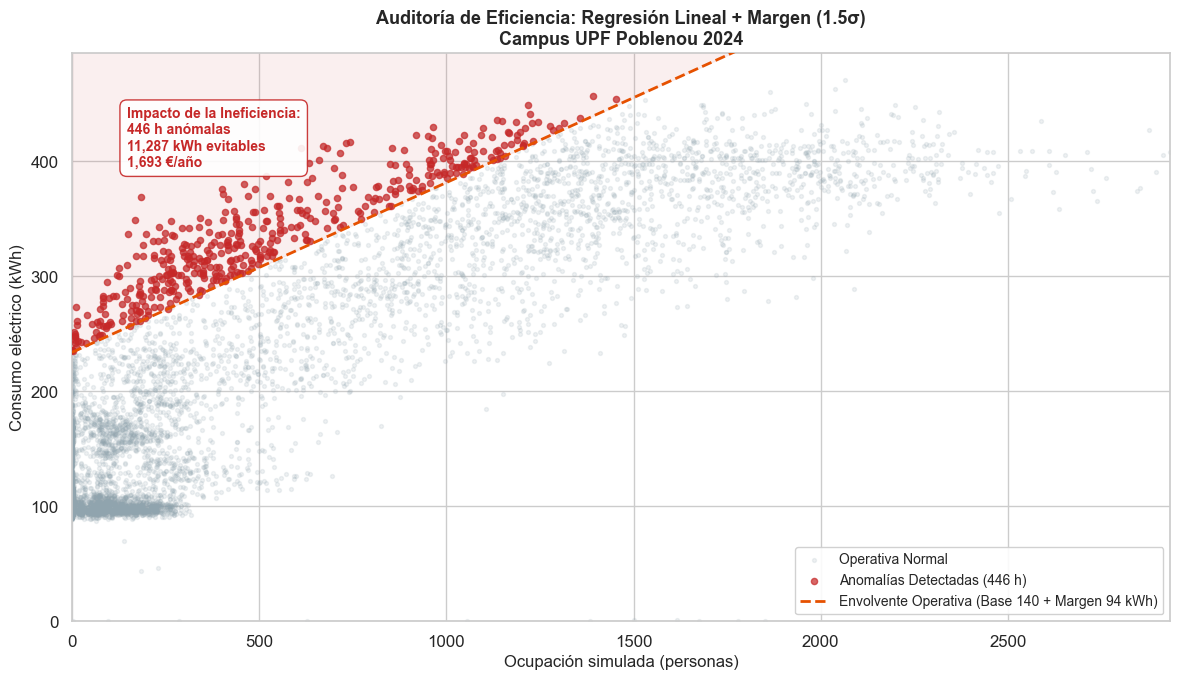

In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))

# --- DIBUJO ---
# 1. Fondo (Horas normales)
ax.scatter(df['Ocupacion_Simulada'], df['Consumo_kWh'],
           alpha=0.15, s=8, color='#90A4AE', label='Operativa Normal', zorder=2)

# 2. Puntos de fuga (Anomalías)
if horas_fuga > 0:
    ax.scatter(fugas['Ocupacion_Simulada'], fugas['Consumo_kWh'],
               alpha=0.7, s=20, color='#C62828',
               label=f'Anomalías Detectadas ({horas_fuga:,} h)', zorder=3)

# 3. Línea diagonal (La Envolvente Operativa calculada por Regresión Lineal)
x_vals = np.array([0, df['Ocupacion_Simulada'].max()])
y_vals = CONSUMO_ARRANQUE_HVAC + (TASA_MARGINAL_PERSONA * x_vals)
ax.plot(x_vals, y_vals, color='#E65100', ls='--', lw=2, zorder=4,
        label=f'Envolvente Operativa (Base {CONSUMO_ARRANQUE_BASE:.0f} + Margen {MARGEN_TOLERANCIA:.0f} kWh)')

# 4. Sombrear la zona de fuga
ax.fill_between(x_vals, y_vals, df['Consumo_kWh'].max() * 1.05, 
                color='#C62828', alpha=0.07, zorder=1)

# 5. Texto informativo con los datos económicos actualizados
texto_impacto = (f'Impacto de la Ineficiencia:\n'
                 f'{horas_fuga:,} h anómalas\n'
                 f'{total_kwh_fuga:,.0f} kWh evitables\n'
                 f'{coste_fuga:,.0f} €/año')

ax.text(df['Ocupacion_Simulada'].max() * 0.05, df['Consumo_kWh'].max() * 0.95,
        texto_impacto, ha='left', va='top', fontsize=10, color='#C62828', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#C62828', alpha=0.9))

ax.set_xlabel('Ocupación simulada (personas)', fontsize=12)
ax.set_ylabel('Consumo eléctrico (kWh)', fontsize=12)
ax.set_title('Auditoría de Eficiencia: Regresión Lineal + Margen (1.5σ)\nCampus UPF Poblenou 2024', 
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_xlim(left=0, right=df['Ocupacion_Simulada'].max())
ax.set_ylim(bottom=0, top=df['Consumo_kWh'].max() * 1.05)

plt.tight_layout()
plt.savefig(FIGURES / 'ahorro_scatter_fugas_ML.png', dpi=150, bbox_inches='tight')
plt.show()

## Figura 2 — Heatmap del desperdicio (hora × mes)

Muestra **cuándo** se desperdicia más: permite identificar patrones
accionables (p.ej. ajustar el arranque del HVAC en meses de transición).

C:\Users\jordi\AppData\Local\Temp\ipykernel_22908\869407170.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jordi\AppData\Local\Temp\ipykernel_22908\869407170.py:62: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(FIGURES / 'ahorro_heatmap_desperdicio_ML.png', dpi=200, bbox_inches='tight')
c:\Users\jordi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


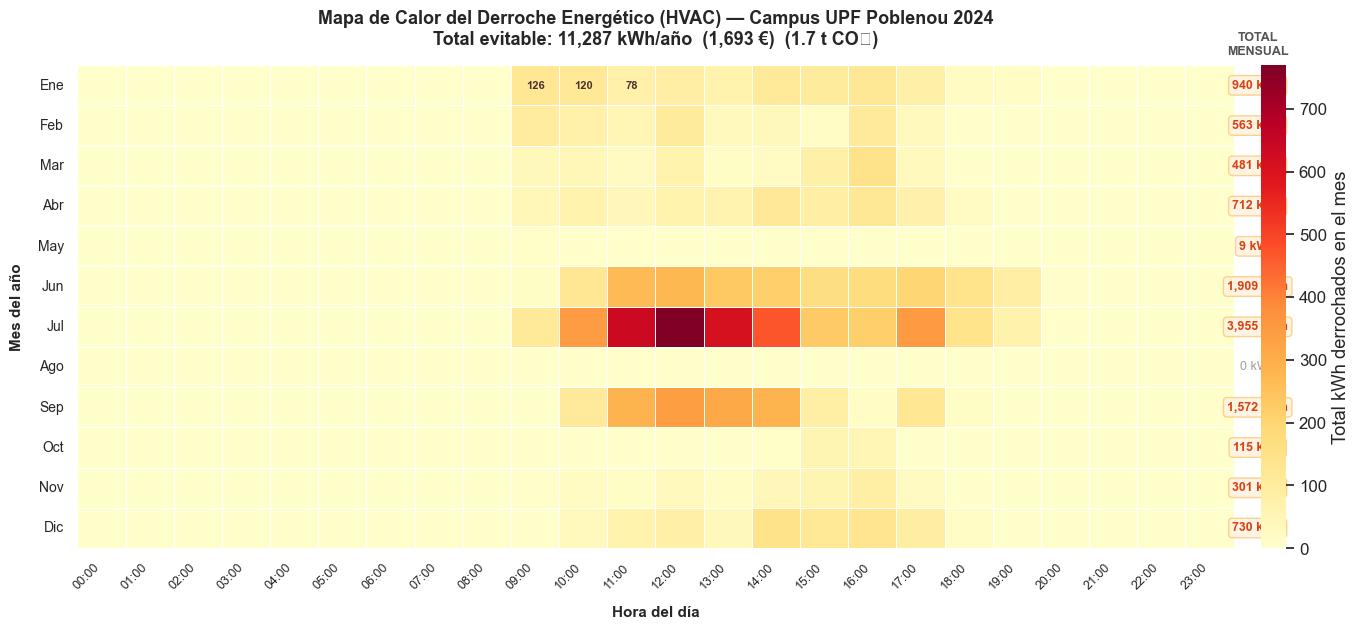

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Usar la matemática correcta (La Envolvente Operativa de la Regresión Lineal)
df['kWh_Evitable'] = 0.0
mask_fuga = df['Consumo_kWh'] > df['Limite_Eficiencia']

df.loc[mask_fuga, 'kWh_Evitable'] = (
    df.loc[mask_fuga, 'Consumo_kWh'] - df.loc[mask_fuga, 'Limite_Eficiencia']
)

# 2. Pivot: filas=mes, columnas=hora. Cambiamos mean() por sum()
heat = df.groupby(['mes','hora'])['kWh_Evitable'].sum().unstack(fill_value=0)
heat.index = [MESES[m-1] for m in heat.index]

# Truco Pro: Crear una matriz de texto que SOLO muestre números si el derroche es grande
# Así no ensuciamos el gráfico lleno de "0" o números diminutos.
annot_labels = heat.map(lambda x: f"{x:,.0f}" if x > 20 else "")

# 3. Dibujar
fig, ax = plt.subplots(figsize=(15, 6.5))

# Usamos 'YlOrRd' (Amarillo-Naranja-Rojo) que resalta mucho mejor los puntos críticos
sns.heatmap(
    heat, cmap='YlOrRd', linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Total kWh derrochados en el mes', 'pad': 0.02},
    annot=annot_labels, fmt="", annot_kws={"size": 8, "weight": "bold", "color": "#4E342E"},
    ax=ax
)

# 4. Panel lateral de totales mensual (Mejorado visualmente)
totales_mes = heat.sum(axis=1)

# Creamos un pequeño encabezado para la columna extra
ax.text(24.5, -0.2, 'TOTAL\nMENSUAL', va='bottom', ha='center', 
        fontsize=9, fontweight='bold', color='#555')

for i, (mes_nombre, total) in enumerate(totales_mes.items()):
    # Dibujamos cajas de texto elegantes en lugar de texto flotante
    if total > 0:
        ax.text(24.5, i + 0.5, f'{total:,.0f} kWh',
                va='center', ha='center', fontsize=9, fontweight='bold', color='#D84315',
                bbox=dict(boxstyle='round,pad=0.3', fc='#FFF3E0', ec='#FFCC80', alpha=0.9))
    else:
        ax.text(24.5, i + 0.5, '0 kWh',
                va='center', ha='center', fontsize=9, color='#9E9E9E')

# 5. Textos y títulos
ax.set_title(
    f'Mapa de Calor del Derroche Energético (HVAC) — Campus UPF Poblenou 2024\n'
    f'Total evitable: {total_kwh_fuga:,.0f} kWh/año  '
    f'({coste_fuga:,.0f} €)  '
    f'({total_kwh_fuga * KG_CO2_PER_KWH / 1000:.1f} t CO₂)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Hora del día', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Mes del año', fontsize=11, fontweight='bold', labelpad=10)
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES / 'ahorro_heatmap_desperdicio_ML.png', dpi=200, bbox_inches='tight')
plt.show()

## Figura 3 — Tres escenarios de ahorro

C:\Users\jordi\AppData\Local\Temp\ipykernel_22908\1220875675.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres_esc, rotation=12, ha='right', fontsize=9)
C:\Users\jordi\AppData\Local\Temp\ipykernel_22908\1220875675.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres_esc, rotation=12, ha='right', fontsize=9)
C:\Users\jordi\AppData\Local\Temp\ipykernel_22908\1220875675.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres_esc, rotation=12, ha='right', fontsize=9)
C:\Users\jordi\AppData\Local\Temp\ipykernel_22908\1220875675.py:35: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jordi\AppData\Local\Temp\ipyk

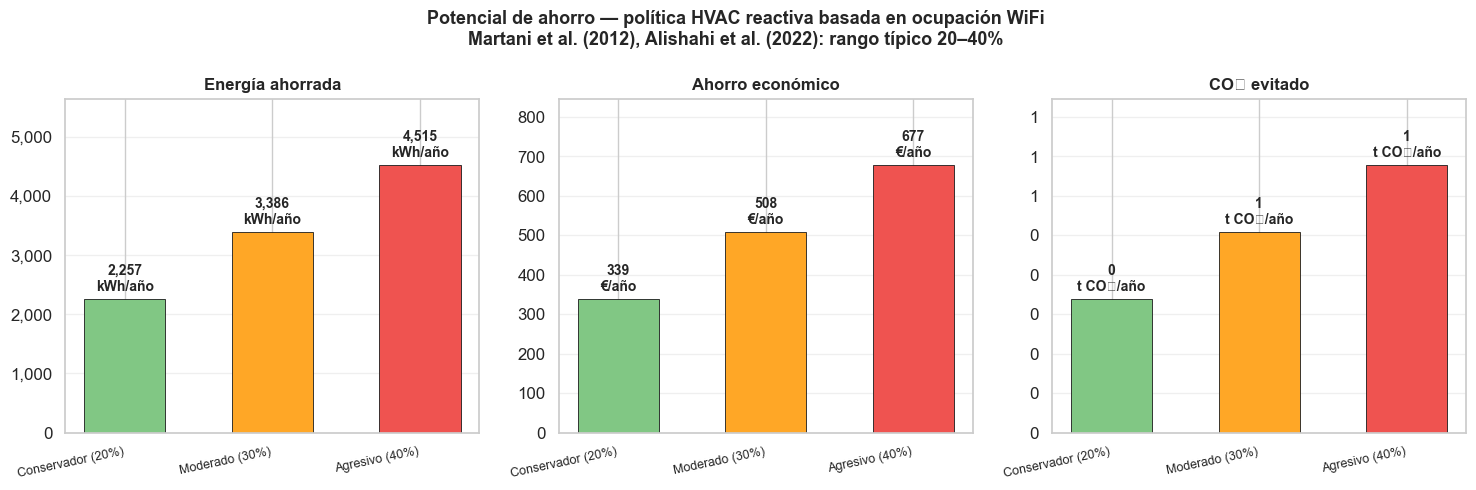

✅ Guardado: ahorro_escenarios.png


In [28]:
nombres_esc  = list(ESCENARIOS.keys())
tasas_esc    = list(ESCENARIOS.values())
ahorros_eur  = [coste_fuga * t for t in tasas_esc]
ahorros_co2  = [total_kwh_fuga * t * KG_CO2_PER_KWH / 1000 for t in tasas_esc]
ahorros_kwh  = [total_kwh_fuga * t for t in tasas_esc]
colores_esc  = ['#81C784', '#FFA726', '#EF5350']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, vals, unidad, titulo in zip(
    axes,
    [ahorros_kwh, ahorros_eur, ahorros_co2],
    ['kWh/año', '€/año', 't CO₂/año'],
    ['Energía ahorrada', 'Ahorro económico', 'CO₂ evitado']
):
    bars = ax.bar(nombres_esc, vals, color=colores_esc,
                   edgecolor='k', linewidth=0.6, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                 val + max(vals)*0.02,
                 f'{val:,.0f}\n{unidad}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.grid(alpha=0.3, axis='y')
    ax.set_xticklabels(nombres_esc, rotation=12, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x:,.0f}'))

plt.suptitle(
    'Potencial de ahorro — política HVAC reactiva basada en ocupación WiFi\n'
    'Martani et al. (2012), Alishahi et al. (2022): rango típico 20–40%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES / 'ahorro_escenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ahorro_escenarios.png')

## Figura 4 — Desperdicio por tipo de día

¿En qué tipo de día se concentra el desperdicio?  
Permite priorizar las políticas de ahorro.

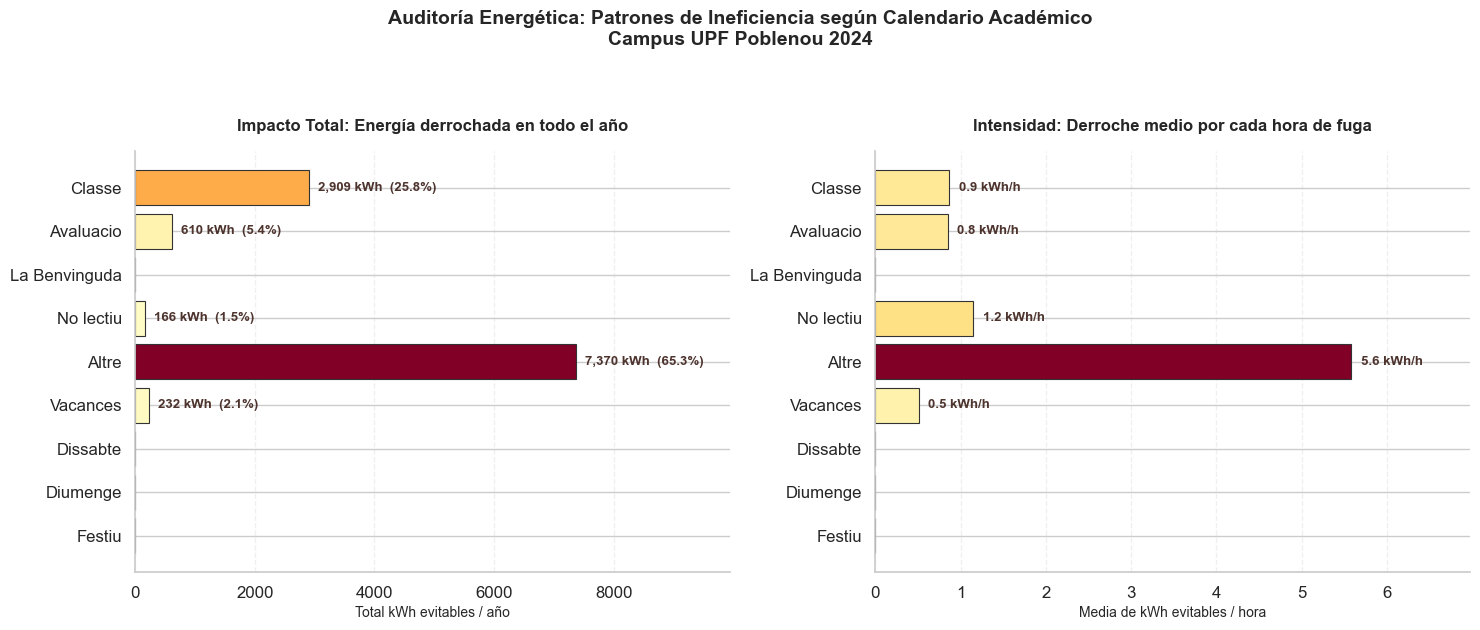


📊 Resumen Financiero por Tipo de Día:
    tipus_dia  horas_totales kwh_evitable eur_evitable pct_del_total
       Classe           3361    2,909 kWh        436 €        25.8 %
    Avaluacio            720      610 kWh         92 €         5.4 %
La Benvinguda             96        0 kWh          0 €         0.0 %
    No lectiu            144      166 kWh         25 €         1.5 %
        Altre           1320    7,370 kWh      1,105 €        65.3 %
     Vacances            454      232 kWh         35 €         2.1 %
     Dissabte           1248        0 kWh          0 €         0.0 %
     Diumenge           1248        0 kWh          0 €         0.0 %
       Festiu            192        0 kWh          0 €         0.0 %


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Columna de tipo de día
COL_TIPUS = 'tipus_dia' if 'tipus_dia' in df.columns else 'Tipus_Dia'

resum_tipus = df.groupby(COL_TIPUS).agg(
    horas_totales   = ('Consumo_kWh',  'count'),
    kwh_evitable    = ('kWh_Evitable', 'sum'),
    kwh_evitable_h  = ('kWh_Evitable', 'mean'),
    consumo_medio   = ('Consumo_kWh',  'mean'),
).reset_index()

# Calcular porcentajes y euros (evitando divisiones por cero)
total_evitable = resum_tipus['kwh_evitable'].sum()
resum_tipus['pct_del_total'] = (resum_tipus['kwh_evitable'] / total_evitable * 100).fillna(0)
resum_tipus['eur_evitable'] = resum_tipus['kwh_evitable'] * PRECIO_KWH

# Definir orden académico lógico
ORDRE = ['Classe', 'Avaluacio', 'La Benvinguda', 'No lectiu', 
         'Altre', 'Vacances', 'Dissabte', 'Diumenge', 'Festiu']

# Filtrar solo los tipos que existan realmente en tus datos
ordre_disp = [t for t in ORDRE if t in resum_tipus[COL_TIPUS].values]

# Reindexar para forzar el orden académico
resum_tipus = resum_tipus.set_index(COL_TIPUS).loc[ordre_disp].reset_index()

# --- TRUCO PRO: Mapas de color dinámicos según el valor real del derroche ---
norm1 = plt.Normalize(0, resum_tipus['kwh_evitable'].max())
colores_t1 = plt.cm.YlOrRd(norm1(resum_tipus['kwh_evitable']))

norm2 = plt.Normalize(0, resum_tipus['kwh_evitable_h'].max())
colores_t2 = plt.cm.YlOrRd(norm2(resum_tipus['kwh_evitable_h']))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── PANEL IZQUIERDO: Impacto Total ──────────────────────────────────────────
bars1 = axes[0].barh(resum_tipus[COL_TIPUS], resum_tipus['kwh_evitable'],
                     color=colores_t1, edgecolor='#333333', linewidth=0.8)

# Textos más limpios e informativos
for bar, pct, val in zip(bars1, resum_tipus['pct_del_total'], resum_tipus['kwh_evitable']):
    if val > 0: # Solo pintar texto si hay fuga
        axes[0].text(bar.get_width() + resum_tipus['kwh_evitable'].max()*0.02,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:,.0f} kWh  ({pct:.1f}%)', 
                     va='center', fontsize=9.5, fontweight='bold', color='#4E342E')

axes[0].set_title('Impacto Total: Energía derrochada en todo el año', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Total kWh evitables / año', fontsize=10)
axes[0].invert_yaxis() # <-- CLAVE: Gira el eje para que "Classe" quede arriba de la tabla
axes[0].grid(alpha=0.3, axis='x', linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── PANEL DERECHO: Intensidad (Derroche por Hora) ───────────────────────────
bars2 = axes[1].barh(resum_tipus[COL_TIPUS], resum_tipus['kwh_evitable_h'],
                     color=colores_t2, edgecolor='#333333', linewidth=0.8)

for bar, val in zip(bars2, resum_tipus['kwh_evitable_h']):
    if val > 0:
        axes[1].text(bar.get_width() + resum_tipus['kwh_evitable_h'].max()*0.02,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:.1f} kWh/h', 
                     va='center', fontsize=9.5, fontweight='bold', color='#4E342E')

axes[1].set_title('Intensidad: Derroche medio por cada hora de fuga', fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Media de kWh evitables / hora', fontsize=10)
axes[1].invert_yaxis() # <-- Sincronizado con el izquierdo
axes[1].grid(alpha=0.3, axis='x', linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Extender el límite X de ambos ejes un poco para que quepan los textos
axes[0].set_xlim(0, resum_tipus['kwh_evitable'].max() * 1.35)
axes[1].set_xlim(0, resum_tipus['kwh_evitable_h'].max() * 1.25)

plt.suptitle('Auditoría Energética: Patrones de Ineficiencia según Calendario Académico\nCampus UPF Poblenou 2024',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()

plt.savefig(FIGURES / 'ahorro_por_tipo_dia_ML.png', dpi=200, bbox_inches='tight')
plt.show()

# ── TABLA DE RESUMEN POR CONSOLA ──────────────────────────────────────────────
print('\n📊 Resumen Financiero por Tipo de Día:')
resumen_limpio = resum_tipus[[COL_TIPUS, 'horas_totales', 'kwh_evitable', 'eur_evitable', 'pct_del_total']].copy()
# Formateo visual para la consola
resumen_limpio['kwh_evitable'] = resumen_limpio['kwh_evitable'].apply(lambda x: f"{x:,.0f} kWh")
resumen_limpio['eur_evitable'] = resumen_limpio['eur_evitable'].apply(lambda x: f"{x:,.0f} €")
resumen_limpio['pct_del_total'] = resumen_limpio['pct_del_total'].apply(lambda x: f"{x:.1f} %")
print(resumen_limpio.to_string(index=False))

In [30]:
esc_mod_eur = coste_fuga * ESCENARIOS['Moderado (30%)']
esc_mod_co2 = total_kwh_fuga * ESCENARIOS['Moderado (30%)'] * KG_CO2_PER_KWH / 1000

report = f"""
ENERGY AUDIT — UPF POBLENOU 2024
══════════════════════════════════════════════════
Mètode: Regressió lineal + marge 1.5σ
  Base teòrica (c):      {CONSUMO_ARRANQUE_BASE:.1f} kWh
  Taxa marginal (m):     {TASA_MARGINAL_PERSONA:.4f} kWh/persona
  Marge tolerància:     +{MARGEN_TOLERANCIA:.1f} kWh (1.5σ)
  Llindar a 0 persones:  {CONSUMO_ARRANQUE_HVAC:.1f} kWh

Hores d'ineficiència: {horas_fuga:,} ({pct_horas_fuga:.1f}% de l'any)
Energia evitable:     {total_kwh_fuga:,.0f} kWh/any
Cost del malbaratament: {coste_fuga:,.0f} €/any

Escenari moderat (30%): {esc_mod_eur:,.0f} €/any  |  {esc_mod_co2:.1f} t CO₂/any
══════════════════════════════════════════════════
"""
print(report)
with open(REPORTS / 'energy_audit.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print('✅ energy_audit.txt guardat')


ENERGY AUDIT — UPF POBLENOU 2024
══════════════════════════════════════════════════
Mètode: Regressió lineal + marge 1.5σ
  Base teòrica (c):      139.5 kWh
  Taxa marginal (m):     0.1477 kWh/persona
  Marge tolerància:     +94.3 kWh (1.5σ)
  Llindar a 0 persones:  233.9 kWh

Hores d'ineficiència: 446 (5.1% de l'any)
Energia evitable:     11,287 kWh/any
Cost del malbaratament: 1,693 €/any

Escenari moderat (30%): 508 €/any  |  0.5 t CO₂/any
══════════════════════════════════════════════════

✅ energy_audit.txt guardat
